# **Using SBERT and Multinomial Logistic Regression for emotion detection**

The Emotions Simplified Dataset on Kaggle (https://www.kaggle.com/datasets/sadamumer/emotions-simplified-dataset-28-classes-from-text) is a simplified version of Google’s official GoEmotions dataset, containing 54263 samples of real Reddit-style comments. Each text sample is assigned a single primary emotion label from one of the 28 emotion classes.

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install contractions
!pip install gensim
import shutil
import random
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
import re
from gensim.models import Word2Vec
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import accuracy_score
from sentence_transformers import SentenceTransformer
from sklearn.preprocessing import normalize
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 345.1/345.1 kB 17.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 56.8 MB/s eta 0:00:00


In [3]:
# After creating a new token from Kaggle's account settings, download and upload the kaggle.json file
# to google drive (only need to be done once). Then upload it to google colab
shutil.copy("/content/drive/MyDrive/kaggle.json", "/content")

'/content/kaggle.json'

In [4]:
# Set the environment to the place that contains the kaggle.json file
!mkdir ~/.kaggle
!cp kaggle.json ~/.kaggle/n
!chmod 600 ~/.kaggle/kaggle.json

chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory


In [5]:
# Download and unzip "emotions_dataset_xv.csv" and "emotions.txt" files from Kaggle to main folder '/content/' of Google Colab
# (check by clicking on the folder icon on the left of the screen)
%cd /content/
!kaggle datasets download sadamumer/emotions-simplified-dataset-28-classes-from-text
!unzip -q 'emotions-simplified-dataset-28-classes-from-text.zip'

/content
Dataset URL: https://www.kaggle.com/datasets/sadamumer/emotions-simplified-dataset-28-classes-from-text
License(s): apache-2.0
100% 1.67M/1.67M [00:00<00:00, 2.88MB/s]



In [6]:
random.seed(10)
np.random.seed(10)

# Load the text samples .csv file
df = pd.read_csv('/content/emotions_dataset_xv.csv')
df.head()

,Text,GE_indices
0,My favourite food is anything I didn't have to...,27
1,"Now if he does off himself, everyone will thin...",27
2,WHY THE FUCK IS BAYLESS ISOING,2
3,To make her feel threatened,14
4,Dirty Southern Wankers,3


In [7]:
# Load the GE_indices emotion mapping .txt file
labels = pd.read_csv('/content/emotions.txt', header=None)
labels

,0
0,admiration
1,amusement
2,anger
3,annoyance
4,approval
5,caring
6,confusion
7,curiosity
8,desire
9,disappointment


In [8]:
# Check samples with more than one value in GE_indices
multi_lab = df[df["GE_indices"].str.contains(",", na=False)]
multi_lab.head()

,Text,GE_indices
7,We need more boards and to create a bit more s...,"8,20"
11,"Aww... she'll probably come around eventually,...","1,4"
15,"Shit, I guess I accidentally bought a Pay-Per-...","3,12"
19,Maybe that’s what happened to the great white ...,"6,22"
20,"I never thought it was at the same moment, but...","6,9,27"


In [9]:
len(multi_lab)

8817

Although the dataset was defined as a single-label simplification of GoEmotions, 8817 samples (16% of data) still contain multiple emotion indices. To obtain a strictly single-label dataset, the multi-labeled samples are removed. This results in a reduced dataset, but ensures alignment with the single-label assumption.

In [10]:
# Remove multi-labeled samples
df = df[df["GE_indices"].str.contains(",", na=False) == False]
df.head()

,Text,GE_indices
0,My favourite food is anything I didn't have to...,27
1,"Now if he does off himself, everyone will thin...",27
2,WHY THE FUCK IS BAYLESS ISOING,2
3,To make her feel threatened,14
4,Dirty Southern Wankers,3


In [11]:
len(df)

45446

Our dataset now contains 45446 samples.

In [12]:
df = df.rename(columns={"GE_indices": "GE_index"})

# Convert GE_index to integer type
df["GE_index"] = df["GE_index"].astype(int)
df.head()

,Text,GE_index
0,My favourite food is anything I didn't have to...,27
1,"Now if he does off himself, everyone will thin...",27
2,WHY THE FUCK IS BAYLESS ISOING,2
3,To make her feel threatened,14
4,Dirty Southern Wankers,3


In [13]:
# Re-format the labels dataframe
labels = labels.reset_index()    # Turns the default index column into a normal column
labels.columns = ["GE_index", "Emotion"]
labels

,GE_index,Emotion
0,0,admiration
1,1,amusement
2,2,anger
3,3,annoyance
4,4,approval
5,5,caring
6,6,confusion
7,7,curiosity
8,8,desire
9,9,disappointment


For this project, only 4 emotions will be considered: *joy, sadness, anger and fear*.

In [14]:
# Merge labels into df
df = df.merge(labels[["GE_index", "Emotion"]], on="GE_index", how="left")

# Keep only 4 emotions
target_emotions = ["anger", "fear", "joy", "sadness"]
df = df[df["Emotion"].isin(target_emotions)].copy()

# Encode the emotions (0: anger, 1: fear, 2: joy, 3: sadness)
le = LabelEncoder()
df["Label"] = le.fit_transform(df["Emotion"])

df = df.drop(columns=["GE_index"])
df.head()

,Text,Emotion,Label
2,WHY THE FUCK IS BAYLESS ISOING,anger,0
3,To make her feel threatened,fear,1
14,Fucking coward.,anger,0
20,Stupidly stubborn / stubbornly stupid,anger,0
24,"Troll, bro. They know they're saying stupid sh...",anger,0


In [15]:
# Check missing values
df.isna().sum()

,0
Text,0
Emotion,0
Label,0


In [16]:
len(df)

3873

Our dataset now contains 3873 samples.

In [17]:
# Load a pre-trained SBERT sentence embedding model (works best with languages that use Latin script)
model_sbert = SentenceTransformer('all-mpnet-base-v2')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/363 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

In [18]:
# Train - test split as 80:20
X_train, X_test, y_train, y_test = train_test_split(df["Text"], df["Label"], test_size = 0.2, random_state = 10,
                                                    stratify = df["Label"])   # Ensures the training and test sets keep approximately the same class distribution as the original dataset

In [19]:
# Check class distribution in the training set
distribution = y_train.value_counts().sort_index().reset_index()
distribution.columns = ["Label", "Count"]
distribution["Emotion"] = distribution["Label"].map(dict(zip(df["Label"], df["Emotion"])))
distribution

,Label,Count,Emotion
0,0,1012,anger
1,1,442,fear
2,2,842,joy
3,3,802,sadness


There is a moderate class imbalance.

In [20]:
# Encode texts with SBERT model (turn each text into a vector)
X_train_vec = model_sbert.encode(X_train.tolist(), show_progress_bar=True)
X_test_vec = model_sbert.encode(X_test.tolist(), show_progress_bar=True)

Batches:   0%|          | 0/97 [00:00<?, ?it/s]

Batches:   0%|          | 0/25 [00:00<?, ?it/s]

In [21]:
y_train = y_train.values
y_test = y_test.values

In [22]:
# L2 normalization (scales a vector so that its Euclidean norm (vector length) becomes 1)
X_train_vec = normalize(X_train_vec)
X_test_vec = normalize(X_test_vec)

In [23]:
# Train a Multinomial Logistic Regression classifier (an extension of Binary Logistic Regression) on training texts
model_mlr = LogisticRegression(max_iter=5000,              # Maximum number of optimization iterations
                               class_weight="balanced",    # Assign higher weight to rarer classes
                               C = 0.1,                    # Regularization hyperparameter to reduce overfitting, smaller values specify stronger regularization
                               multi_class="multinomial",
                               solver="lbfgs",             # Limited-memory BFGS optimization algorithm
                               random_state = 10)
model_mlr.fit(X_train_vec, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


LogisticRegression(C=0.1, class_weight='balanced', max_iter=5000,
                   multi_class='multinomial', random_state=10)

In [24]:
# Evaluate the model's performance on the training and test set
y_train_pred = model_mlr.predict(X_train_vec)
y_test_pred = model_mlr.predict(X_test_vec)

# Accuracy
train_acc = accuracy_score(y_train, y_train_pred)
print("Training accuracy:", train_acc)
test_acc = accuracy_score(y_test, y_test_pred)
print("Test accuracy:", test_acc, "\n")

# Macro F1 score
train_f1 = f1_score(y_train, y_train_pred, average="macro")
print("Training macro F1 score:",train_f1)
test_f1 = f1_score(y_test, y_test_pred, average="macro")
print("Test macro F1 score:", test_f1, "\n")

# F1 score for each class
emotions = ["anger", "fear", "joy", "sadness"]

test_f1_per_class = f1_score(y_test, y_test_pred, average=None)
print("Test F1 score for each class:")
for emotion, f1 in zip(emotions, test_f1_per_class):
    print(f"{emotion}: {f1:.4f}")

Training accuracy: 0.8040671400903809
Test accuracy: 0.775483870967742 

Training macro F1 score: 0.796705173912664
Test macro F1 score: 0.7624996941754261 

Test F1 score for each class:
anger: 0.8030
fear: 0.6781
joy: 0.8416
sadness: 0.7273


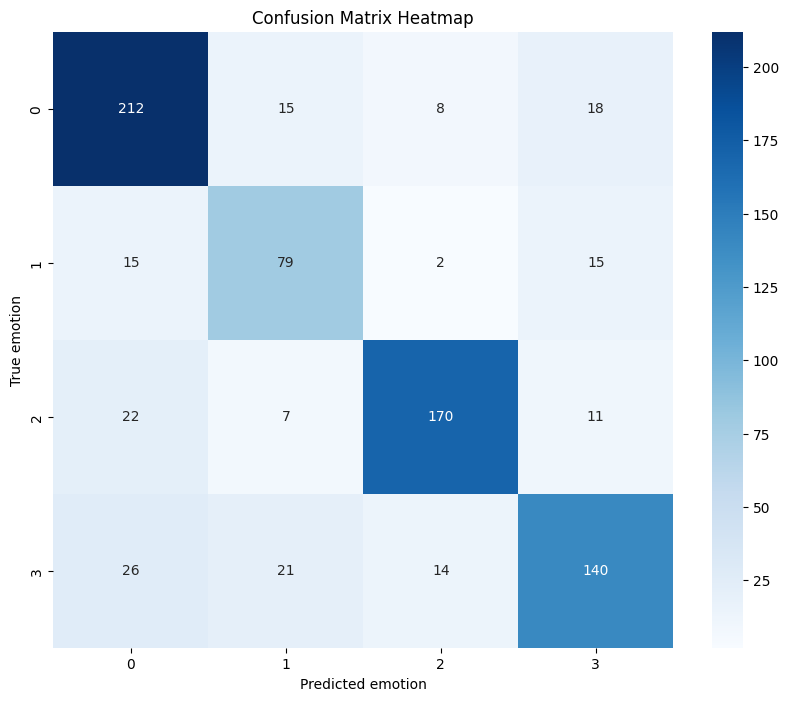

In [25]:
# Confusion matrix heatmap
cm = confusion_matrix(y_test, y_test_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted emotion")
plt.ylabel("True emotion")
plt.title("Confusion Matrix Heatmap")
plt.show()

From the F1 score for each class and the confusion matrix heatmap,
- Class 0 (*anger*): Recall = 212 / 253 = 0.84. Precision = 212 / 275 = 0.77. This class has strong performance, with most errors coming from confusion with class 3 and class 1.
- Class 1 (*fear*): Recall = 79 / 111 = 0.71. Precision = 79 / 122 = 0.65. This class shows weakest performance and is mainly confused with class 0 and class 3.
- Class 2 (*joy*): Recall = 170 / 210 = 0.81. Precision = 170 / 194 = 0.88.This class has strongest performance, with most errors coming from confusion with class 0 and class 3.
- Class 3 (*sadness*): Recall = 140 / 201 = 0.70. Precision = 140 / 184 = 0.76. This class shows moderate performance and is mostly confused with class 0 and class 1.

In [26]:
# Find wrong test predictions
mask = y_test != y_test_pred

df_errors = pd.DataFrame({"Text": X_test[mask],
                          "True emotion": le.inverse_transform(y_test[mask]),
                          "Predicted emotion": le.inverse_transform(y_test_pred[mask])})
df_errors.head()

,Text,True emotion,Predicted emotion
25030,That blows. Glad you're doing better.,joy,sadness
7768,You look like a failed attempt to gene splice ...,sadness,fear
23845,"While this makes me happy to know, it would pr...",joy,fear
28874,Did that with an oven pizza at 3am in my under...,sadness,fear
37861,Venezuela has uniquely terrible oil.,fear,anger


In [27]:
# Prediction example
new_text = "I don't feel good today."

new_text_vec = model_sbert.encode(new_text)
new_text_vec = normalize(new_text_vec.reshape(1, -1))

new_label_pred = model_mlr.predict(new_text_vec)
new_emotion_pred = le.inverse_transform(new_label_pred)

print(new_text, " -> ", new_emotion_pred)

I don't feel good today.  ->  ['sadness']
